# 01_回归算法-线性回归

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇数据：`dataset/housing.csv`。

转写调整：

- 从本地 housing.csv 构造加州房价特征，删除缺失行，固定抽样 2500 行；load_local_housing(sample_size=None) 可运行全量有效数据。
- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。
- 监督式特征选择只在训练集拟合，测试集仅应用相同变换。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


简单来说，线性回归主要用来找出两个变量之间的关系。

我们可以用它来预测一个变量（通常叫做因变量或目标变量）是如何随着另一个变量（通常叫做自变量或特征变量）变化的。

### 什么是线性回归？

想象你有一堆数据点，每个点都有两个值，比如说房子的大小和价格。你想要找出一个简单的规律，来预测房子的价格会随着房子的大小如何变化。

这时候，线性回归就派上用场了。

线性回归的目标是找到一条直线，这条直线尽可能贴近这些数据点。这个过程叫做“拟合”数据。简单来说，就是找出一个公式，类似于 y = mx + b，这个公式告诉你房子的价格（y）和房子的大小（x）之间的关系。

- **y**：这是你想要预测的值，比如房子的价格。
- **x**：这是你已知的值，比如房子的大小。
- **m**：这是斜率，表示房子的大小每增加一个单位，价格会增加多少。
- **b**：这是截距，表示当房子的大小为零时，价格是多少（虽然在实际中房子的大小不可能是零，但数学上需要这个值）。

### 举个简单例子

假设你有以下几个房子的大小和价格：

- 房子1：大小100平方米，价格200万
- 房子2：大小150平方米，价格250万
- 房子3：大小200平方米，价格300万

你希望找到一个公式，能够预测其他大小房子的价格。通过线性回归，你可能会得到一个公式，比如 y = x + 100. 这意味着每平方米的大小对应的价格是2万，而且即使房子大小是零，起价也是0万（这个仅仅是为了公式完整，在现实中并不实际）。

### 为什么要用线性回归？

1. **简单易懂**：线性回归的结果是一个简单的直线公式，容易理解和解释。
2. **快速计算**：计算线性回归的参数（斜率和截距）非常快速。
3. **广泛应用**：很多实际问题都可以用线性回归来解决，比如预测房价、销售额、温度变化等。

## 理论基础

线性回归的目标是找到一条直线 $y = mx + b$，使得这条直线能够最好地拟合数据。

这里，$m$是斜率，$b$是截距。为了找到最佳的 $m$和 $b$，我们需要最小化预测值和实际值之间的误差。

### 公式推导

1. **假设模型**：


$$
y = \beta_0 + \beta_1 x + \epsilon
$$


1. 这里 $\beta_0$是截距，$\beta_1$是斜率，$\epsilon$是误差项。
2. **误差平方和**：
3. 为了衡量模型的好坏，我们用误差平方和来表示：


$$
SSE = \sum_{i=1}^{n} (y_i - (\beta_0 + \beta_1 x_i))^2
$$


1. **最小化误差平方和**：
2. 我们需要找到 $\beta_0$ 和 $\beta_1$ 使得 SSE 最小。对 SSE 关于 $\beta_0$ 和 $\beta_1$ 求偏导数，并令其为零，得到：


$$
\frac{\partial SSE}{\partial \beta_0} = -2 \sum_{i=1}^{n} (y_i - (\beta_0 + \beta_1 x_i)) = 0
$$


$$
\frac{\partial SSE}{\partial \beta_1} = -2 \sum_{i=1}^{n} x_i (y_i - (\beta_0 + \beta_1 x_i)) = 0
$$


1. **求解方程**：
2. 将以上两个方程展开并整理，可以得到：


$$
\beta_0 n + \beta_1 \sum_{i=1}^{n} x_i = \sum_{i=1}^{n} y_i
$$


$$
\beta_0 \sum_{i=1}^{n} x_i + \beta_1 \sum_{i=1}^{n} x_i^2 = \sum_{i=1}^{n} x_i y_i
$$


1. 这是一组线性方程组，可以解出 $\beta_0$ 和 $\beta_1$：


$$
\beta_1 = \frac{n \sum_{i=1}^{n} x_i y_i - \sum_{i=1}^{n} x_i \sum_{i=1}^{n} y_i}{n \sum_{i=1}^{n} x_i^2 - (\sum_{i=1}^{n} x_i)^2}
$$


$$
\beta_0 = \bar{y} - \beta_1 \bar{x}
$$


1. 其中，$\bar{x}$ 和 $\bar{y}$ 分别是 $x$ 和 $y$ 的均值。

### 算法流程

1. **收集数据**：获得一组包含自变量 $x$ 和因变量 $y$ 的数据点。
2. **计算均值**：


$$
\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i
$$


$$
\bar{y} = \frac{1}{n} \sum_{i=1}^{n} y_i
$$


1. **计算斜率** $\beta_1$：


$$
\beta_1 = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{n} (x_i - \bar{x})^2}
$$


1. **计算截距** $\beta_0$：


$$
\beta_0 = \bar{y} - \beta_1 \bar{x}
$$


1. **构建模型**：得到回归方程 $y = \beta_0 + \beta_1 x$。
2. **模型评估**：$MSE = \frac{1}{n} \sum_{i=1}^{n} e_i^2$；$R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y_i})^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$

   - 计算预测值 $\hat{y_i} = \beta_0 + \beta_1 x_i$。
   - 计算残差 $e_i = y_i - \hat{y_i}$。
   - 计算均方误差（Mean Squared Error, MSE）：

   - 计算 $R^2$ 决定系数来评估模型的拟合优度：

线性回归的核心思想是通过最小化误差平方和来找到最优的直线拟合数据。通过计算均值和斜率，可以得出回归方程。然后，通过模型评估指标来判断模型的拟合效果。

这个过程涉及到基本的微积分和线性代数，但本质上是通过找到最优参数来使得模型对数据的预测最准确。

## 完整案例

咱们使用加州房价数据集来进行线性回归分析。

这个数据集包含加州地区的房屋特征和对应的房价中位数。

整个代码的步骤：

1. 加载和预处理数据
2. 构建线性回归模型
3. 可视化数据和模型结果
4. 评估模型性能
5. 进行算法优化

### 1. 加载和预处理数据

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from notebook_support import load_local_housing
# 加载加州房价数据集
california = load_local_housing()
data = pd.DataFrame(california.data, columns=california.feature_names)
data['MedHouseVal'] = california.target

# 查看数据集
print(data.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  3.1838      20.0  3.783465   1.094488       525.0  2.066929     32.79   
1  4.4871       2.0  6.690700   1.166144      3327.0  3.476489     38.01   
2  3.2237      31.0  4.657928   1.064919      2313.0  2.887640     33.92   
3  2.8920      30.0  5.701357   1.248869       707.0  3.199095     37.94   
4  4.1016       4.0  4.709328   1.295011       928.0  2.013015     37.99   

   Longitude  MedHouseVal  
0    -117.24        2.458  
1    -121.29        1.379  
2    -118.14        2.182  
3    -122.07        2.208  
4    -121.89        1.705  


### 2. 构建线性回归模型

将数据分为训练集和测试集，训练线性回归模型。

In [3]:
# 分离特征变量和目标变量
X = data.drop('MedHouseVal', axis=1)
y = data['MedHouseVal']

# 拆分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 构建线性回归模型
model = LinearRegression()
model.fit(X_train, y_train)

# 预测
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

### 3. 可视化数据和模型结果

可视化真实值与预测值的关系，以及残差分布。

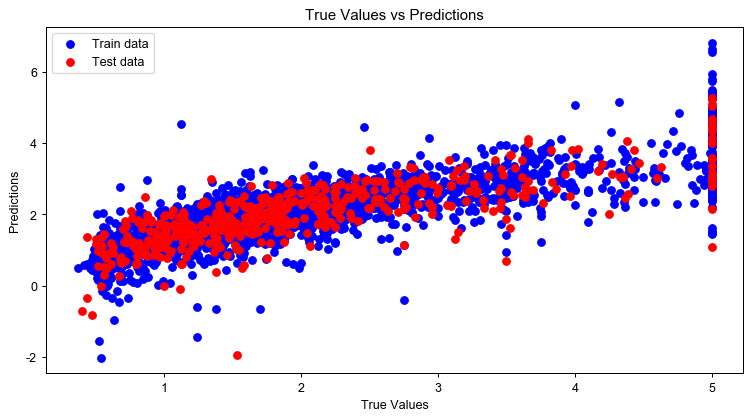

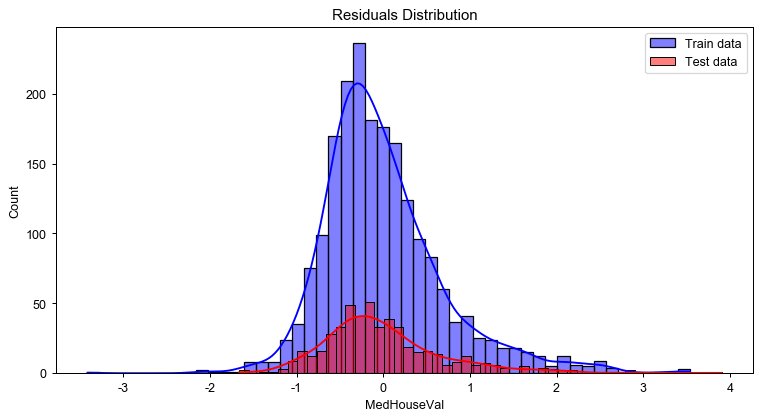

In [4]:
# 真实值 vs 预测值
plt.figure(figsize=(10, 5))
plt.scatter(y_train, y_train_pred, color='blue', label='Train data')
plt.scatter(y_test, y_test_pred, color='red', label='Test data')
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.legend()
plt.title('True Values vs Predictions')
plt.show()

# 残差分布
plt.figure(figsize=(10, 5))
sns.histplot((y_train - y_train_pred), bins=50, kde=True, label='Train data', color='blue')
sns.histplot((y_test - y_test_pred), bins=50, kde=True, label='Test data', color='red')
plt.legend()
plt.title('Residuals Distribution')
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_017.png)

![原文参考图，当前结果见代码输出](attachments/img_018.png)

### 4. 评估模型性能

使用均方误差（MSE）和 $R^2$ 决定系数来评估模型。

In [5]:
# 评估训练集性能
mse_train = mean_squared_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

# 评估测试集性能
mse_test = mean_squared_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print(f'Train MSE: {mse_train}, Train R2: {r2_train}')
print(f'Test MSE: {mse_test}, Test R2: {r2_test}')

Train MSE: 0.5010229218300044, Train R2: 0.636221155061754
Test MSE: 0.5021292166440726, Test R2: 0.6005520966397506


### 5. 进行算法优化

通过特征选择和标准化来优化模型。

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression

# 特征选择
selector = SelectKBest(f_regression, k=6)
X_train_new = selector.fit_transform(X_train, y_train)
X_test_new = selector.transform(X_test)
y_train_new, y_test_new = y_train, y_test

# 数据标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_new)
X_test_scaled = scaler.transform(X_test_new)

# 构建新模型
model_new = LinearRegression()
model_new.fit(X_train_scaled, y_train_new)

# 预测
y_train_pred_new = model_new.predict(X_train_scaled)
y_test_pred_new = model_new.predict(X_test_scaled)

# 评估新模型性能
mse_train_new = mean_squared_error(y_train_new, y_train_pred_new)
r2_train_new = r2_score(y_train_new, y_train_pred_new)
mse_test_new = mean_squared_error(y_test_new, y_test_pred_new)
r2_test_new = r2_score(y_test_new, y_test_pred_new)

print(f'Train MSE (new): {mse_train_new}, Train R2 (new): {r2_train_new}')
print(f'Test MSE (new): {mse_test_new}, Test R2 (new): {r2_test_new}')

Train MSE (new): 0.5049503715361038, Train R2 (new): 0.6333695427793868
Test MSE (new): 0.5063866752546244, Test R2 (new): 0.5971652534542575


### 总结

通过这个完整的案例，我们展示了如何使用线性回归模型预测加州房价，并进行了详细的数据可视化和模型评估。

最后，通过特征选择和标准化，我们进一步优化了模型，提升了其预测性能。

## 模型分析

在这个加州房价预测的案例中，使用了线性回归模型。

### 线性回归模型的优缺点

#### 优点

1. **简单易懂**：线性回归模型的结果是一个简单的线性方程，易于理解和解释。
2. **快速计算**：线性回归的计算速度快，适用于大规模数据集的快速建模。
3. **可解释性强**：线性回归可以清楚地展示每个特征对目标变量的影响，便于进行因果分析。

#### 缺点

1. **假设严格**：线性回归假设自变量和因变量之间存在线性关系，但实际中很多关系是非线性的。
2. **对异常值敏感**：线性回归对异常值非常敏感，这些异常值可以极大地影响模型的参数估计。
3. **特征工程要求高**：需要对特征进行选择、标准化等预处理，否则可能会导致模型性能下降。
4. **多重共线性问题**：当自变量之间存在多重共线性时，模型的稳定性会受到影响。

### 与相似算法的对比

| 算法 | 适用情况 | 优点 | 缺点 |
|-|-|-|-|
| **多项式回归** | 适用于数据存在非线性关系时 | 能拟合复杂的非线性关系 | 高次多项式易过拟合 |
| **决策树回归** | 适用于数据有明显分段特征，或关系非线性且不连续 | 对异常值不敏感，易解释 | 易过拟合 |
| **随机森林回归** | 适用于复杂数据且非线性关系明显 | 比决策树更稳健，不易过拟合 | 计算量大，解释性差 |
| **支持向量机回归（SVR）** | 适用于高维特征数据，尤其是线性不可分数据 | 适用于非线性回归问题，泛化能力强 | 参数选择复杂，计算成本高 |
| **梯度提升回归（GBR）** | 适用于高精度任务，如比赛或高要求预测任务 | 预测精度高，适应复杂关系 | 训练时间长，超参数调整复杂 |
| **线性回归** | 适用于简单线性关系、快速建模、大规模数据 | 计算高效，易解释，适用于金融、医疗等领域 | 不能处理非线性关系，易受异常值影响 |

## 最后

线性回归是一种简单易懂、计算快速的模型，适用于线性关系明显且需要高可解释性的场景。

但是呢，当数据关系复杂、存在异常值或多重共线性时，其他算法如多项式回归、决策树、随机森林、支持向量机或梯度提升可能会提供更好的性能和更高的预测精度。